# 24.2 · Training, validation and devices

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain training, validation and devices using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[23 · CNN Fundamentals](../../23-cnn-fundamentals/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

PyTorch manages tensors, differentiable operations and model parameters. Its convenience does not remove responsibilities for split integrity, device handling, training state and reproducible checkpoints. A clear loop makes these responsibilities visible.

## 2. Intuition

Training and evaluation are different modes. model.train enables training behavior; model.eval changes layers such as dropout and batch normalization. Neither by itself disables autograd. Use inference_mode or no_grad for evaluation. Move model and data to the same available device; CPU is a valid default when CUDA is unavailable.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 24
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
\theta_{t+1}=\theta_t-\eta\nabla_\theta L
$$

θ represents all trainable parameters, η the learning rate and ∇θL the gradient. A weight 0.5 with gradient 0.2 and step 0.1 updates to 0.48. Adam changes this basic rule using moving gradient statistics.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
weight, gradient, learning_rate = 0.5, 0.2, 0.1
updated = weight - learning_rate * gradient
assert np.isclose(updated, 0.48)
print(updated)

0.48


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reusable trainer uses a seeded DataLoader, Adam and explicit train/eval transitions. The notebook reloads weights on CPU and compares logits, catching architecture or state mismatches.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def pytorch_lab(lesson, seed, amount):
    model, history, x, y, prediction = classification_experiment(seed, epochs=3, lr=0.01 * amount)
    with TemporaryDirectory() as directory:
        checkpoint = Path(directory) / "weights.pt"
        torch.save(model.state_dict(), checkpoint)
        restored = TinyCNN()
        restored.load_state_dict(torch.load(checkpoint, map_location="cpu", weights_only=True))
        restored.eval()
        with torch.no_grad():
            error = float((model(x) - restored(x)).abs().max())
    return Result(
        "24 · DataLoader, training, evaluation and checkpoint round trip",
        {
            "Held-out example": x[0, 0].numpy(),
            "Confusion matrix": confusion_matrix(y, prediction, labels=[0, 1, 2]),
        },
        curves={"Training loss": history},
        metrics={
            "checkpoint_max_logit_error": error,
            "held_out_accuracy": float((prediction == y).float().mean()),
            "epochs": 3,
            "batch_size": 16,
            "learning_rate": 0.01 * amount,
        },
    )

{
  "checkpoint_max_logit_error": 0.0,
  "held_out_accuracy": 0.4333333373069763,
  "epochs": 3,
  "batch_size": 16,
  "learning_rate": 0.01
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import train_supervised

display(Code(inspect.getsource(train_supervised), language="python"))

def train_supervised(model, x, y, epochs=6, batch_size=16, lr=0.01, seed=42, segmentation=False):
    """Training-only loop. Caller owns an independent held-out set and evaluation."""
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(x, y), batch_size=batch_size, shuffle=True, generator=generator
    )
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    history = []
    model.train()
    for _ in range(epochs):
        total = 0
        for batch, target in loader:
            optimizer.zero_grad(set_to_none=True)
            prediction = model(batch)
            loss = (
                F.binary_cross_entropy_with_logits(prediction, target)
                if segmentation
                else F.cross_entropy(prediction, target)
            )
            loss.backward()
            optimizer.step()
            total += float(loss.detach()) * len(batch)
        history.append(total / len(x))
    model.eval()
    return history

## 8. Experiment

Resume a training run with and without optimizer state and compare the first update after resuming. Explain why identical weights alone may not reproduce training.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "checkpoint_max_logit_error": 0.0,
    "held_out_accuracy": 0.4333333373069763,
    "epochs": 3,
    "batch_size": 16,
    "learning_rate": 0.01
  },
  "second_seed": {
    "checkpoint_max_logit_error": 0.0,
    "held_out_accuracy": 0.5333333611488342,
    "epochs": 3,
    "batch_size": 16,
    "learning_rate": 0.01
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

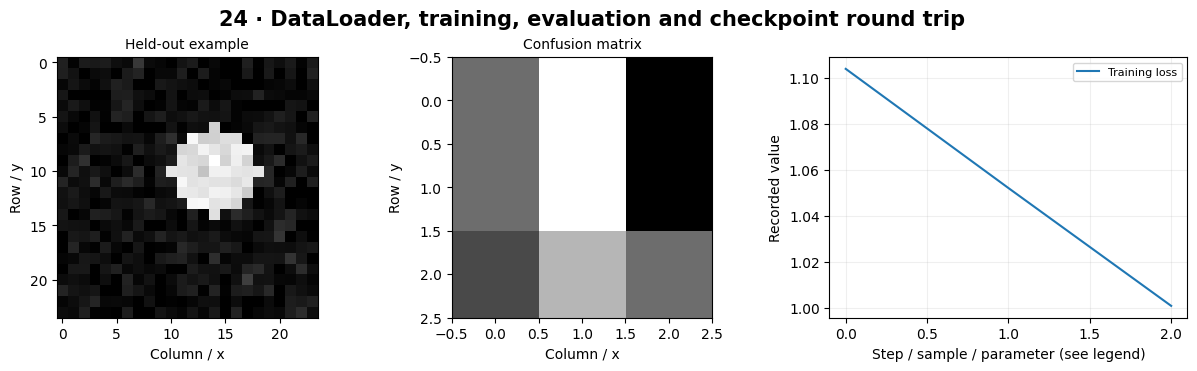

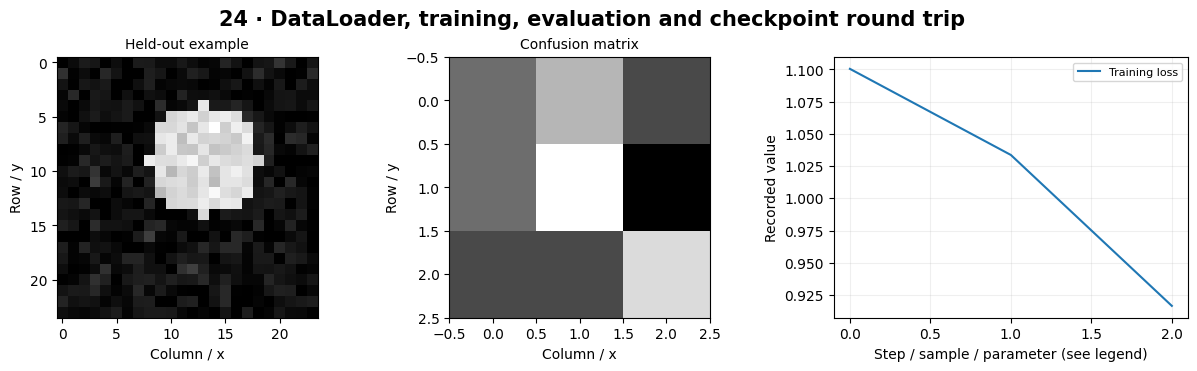

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Reusable Training Engine**. Write a reproducible training and validation loop. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Using a shuffled validation sampler does not inherently bias metrics, but applying random training augmentation can make evaluation unstable.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Resume a training run with and without optimizer state and compare the first update after resuming. Explain why identical weights alone may not reproduce training.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Create a reusable trainer with validation-based checkpoint selection, explicit CPU fallback and a machine-readable experiment manifest.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Training and evaluation are different modes. model.train enables training behavior; model.eval changes layers such as dropout and batch normalization. Neither by itself disables autograd. Use inference_mode or no_grad for evaluation. Move model and data to the same available device; CPU is a valid default when CUDA is unavailable.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Checkpoints, AMP and experiment records** in this chapter.

[Primary reference](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)